# US Firm Characteristics: Feature Evaluation

The panel built in the previous notebook offers fifty-odd accounting and price-based
characteristics as candidate predictors of next month's return. Most of them will not
predict it, a few will, and testing them all at once guarantees that some of the ones that
look convincing are convincing by accident. This notebook measures each candidate against
the label one at a time, records how strong and how stable that association is, charges the
search for the number of candidates it looked at, and writes one decision per candidate.

It decides nothing about the strategy. A characteristic that ranks firms well may still be
unprofitable once it is combined with the others and traded at cost. The model and backtest
notebooks that follow are where that is settled.

## Learning objectives

- Measure how well one characteristic sorts firms by next month's return: rank both across
  the firms trading in the same month, correlate the two rankings, and average that
  correlation over the months of the sample
- Widen the error bars on that average to allow for the months being related to each
  other, and then again for the number of characteristics tested at once, and say what
  each correction is protecting against
- Read the same association separately inside each training-and-validation period, so that
  a characteristic that works throughout the sample is told apart from one that worked in a
  single stretch of it
- Decide which of two characteristics carrying the same evidence to keep, using how strong
  and how steady each one's association is
- Write one decision per characteristic to a file a later notebook can read, without
  deciding anything about the strategy

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.3 sets out how a single feature is evaluated against a label, and
Section 7.4 sets out what a search over many features costs the p-values it produces.
Section 8.6 is the secondary reference for keeping one representative of a group of
near-identical features.

Reads `features/financial.parquet`, the 57 characteristics
[`03_financial_features`](03_financial_features.ipynb) writes;
`labels/fwd_ret_1m.parquet`, the monthly return
[`02_labels`](02_labels.ipynb) writes; and `config/setup.yaml`, which declares the label,
the training and validation periods and the date the held-back period starts.

Writes `evaluation/triage_ledger.parquet`, one row per characteristic with its decision
and the evidence behind it. Chapter 20's `20_strategy_synthesis/02_feature_evaluation`
reads that file for all nine case studies and turns them into one comparison across them.
Also writes `evaluation/ic_timeseries.parquet`, the month-by-month correlation series every
summary below reduces, kept so it can be reread without recomputing it. Both files get a
small JSON record beside them holding a digest of their contents, their row count and the
digests of the two files they were built from.

In [1]:
"""US Firm Characteristics: Feature Evaluation."""

import textwrap
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import (
    compute_ic_hac_stats,
    compute_ic_uncertainty,
    cross_sectional_ic_series,
)
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from case_studies.utils.artifact_digest import read_digest, value_digest, write_artifact
from case_studies.utils.feature_engineering import assign_families, families_from_config
from utils.artifact_specs import load_setup_config, resolve_label_buffer, resolve_label_horizon
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.data_quality import validate_modeling_inputs
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt, zero_line

In [2]:
MAX_SYMBOLS = 0  # 0 runs the full universe; a positive value keeps that many firms

## Configuration

Nine settings decide everything below, and each of them is a judgement someone has to make
for their own data. They are bound once here and printed as statements, because a threshold
retyped further down is a second place the same decision lives.

The label, the walk-forward periods and the date the held-back period starts are not
judgements this notebook makes: they are read from `config/setup.yaml`, the same file the
model notebooks read, so that the periods scored here are the periods those notebooks train
and validate on.

In [3]:
CASE_STUDY_ID = "us_firm_characteristics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

DATE_COL = "timestamp"
ENTITY_COL = "symbol"
JOIN_COLS = [DATE_COL, ENTITY_COL]
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"

SETUP = load_setup_config(CASE_STUDY_ID)
EVAL_CONFIG = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = date.fromisoformat(str(EVAL_CONFIG["holdout_start"])[:10])
N_SPLITS = int(EVAL_CONFIG["n_splits"])

MIN_COVERAGE = 0.70  # a characteristic missing on more than 30% of firm-months is not scored
MIN_CROSS_SECTION = 30  # firms with both values in a month, below which that month is skipped
MIN_IC_MONTHS = 20  # months a characteristic needs before its average is reported at all
MIN_FOLD_MONTHS = 5  # months inside one period, below which that period reports no average
FDR_ALPHA = 0.05  # share of the promotions made on significance allowed to be false
IC_THRESHOLD = 0.01  # association strength the second promotion route requires
MIN_SIGN_CONSISTENCY = 0.60  # share of periods agreeing in direction that route also requires
REDUNDANCY_CUT = 0.70  # correlation above which two characteristics are one piece of evidence
N_QUANTILES = 5  # groups the firms are split into each month for the shape diagnostic

The declared label is a single month's return, so no two consecutive observations of it
share any part of their window. The Newey-West correction below is told that span rather
than a lag count, so the width it allows for is read from `setup.yaml` and not typed here.
`labels.horizons` is a different quantity and is not what the correction wants: it says how
far past its own timestamp an outcome is still unresolved, which on this panel is zero.

In [4]:
LABEL_NAME = SETUP["labels"]["primary"]
LABEL_PATH = CASE_DIR / "labels" / f"{LABEL_NAME}.parquet"
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, LABEL_NAME, SETUP)
OUTCOME_HORIZON = resolve_label_horizon(CASE_STUDY_ID, LABEL_NAME, SETUP)
LABEL_SPAN_MONTHS = int(str(LABEL_BUFFER).rstrip("Mm"))

In [5]:
print(
    "Settings\n"
    f"  label                 {LABEL_NAME}, the return over one month\n"
    f"  development period    every month-end before {HOLDOUT_START}\n"
    f"  held-back period      {HOLDOUT_START} to {EVAL_CONFIG['holdout_end']}, unread here\n"
    f"  periods scored        {N_SPLITS} walk-forward training-and-validation splits\n"
    f"  coverage floor        {MIN_COVERAGE:.0%} of firm-months carrying a value\n"
    f"  cross-section floor   {MIN_CROSS_SECTION} firms in a month, or the month is skipped\n"
    f"  months floor          {MIN_IC_MONTHS} scored months, or the characteristic is not\n"
    f"  false-discovery rate  {FDR_ALPHA:.0%} of the promotions made on significance\n"
    f"  association floor     {IC_THRESHOLD} for the second promotion route\n"
    f"  agreement floor       {MIN_SIGN_CONSISTENCY:.0%} of periods, for that same route\n"
    f"  redundancy cut        correlation of {REDUNDANCY_CUT} between two characteristics\n"
    f"  quantile groups       {N_QUANTILES} per month"
)

Settings
  label                 fwd_ret_1m, the return over one month
  development period    every month-end before 2016-01-01
  held-back period      2016-01-01 to 2016-12-31, unread here
  periods scored        10 walk-forward training-and-validation splits
  coverage floor        70% of firm-months carrying a value
  cross-section floor   30 firms in a month, or the month is skipped
  months floor          20 scored months, or the characteristic is not
  false-discovery rate  5% of the promotions made on significance
  association floor     0.01 for the second promotion route
  agreement floor       60% of periods, for that same route
  redundancy cut        correlation of 0.7 between two characteristics
  quantile groups       5 per month


## A. Panel and the holdout seal: which rows may be looked at

The characteristics and the label are two files, one row per firm-month in each. They are
joined on the firm and the month-end, and the join is required to match every row on both
sides exactly once: a firm-month appearing twice on either side would multiply the panel
and inflate every count and every correlation computed from it afterwards.

Each file carries a digest of its own contents beside it. Recomputing that digest from the
file just read is what tells this notebook that it is reading the version of the panel the
previous stages wrote, rather than an older copy left in place.

In [6]:
features = pl.read_parquet(FEATURES_PATH)
label_df = pl.read_parquet(LABEL_PATH)

features_record = read_digest(FEATURES_PATH)
label_record = read_digest(LABEL_PATH)
assert value_digest(features) == features_record["digest"], "financial.parquet moved"
assert value_digest(label_df) == label_record["digest"], f"{LABEL_NAME}.parquet moved"

CANDIDATES = [c for c in features.columns if c not in JOIN_COLS]
full_panel = features.join(label_df, on=JOIN_COLS, how="inner", validate="1:1")
assert len(full_panel) == len(features) == len(label_df)

### The held-back period

A held-back period is a stretch at the end of the sample that nothing in the research is
allowed to look at, so that a single final measurement can be taken on data no choice was
made against. Every count, correlation and decision below is computed on the months before
it, and that is asserted rather than described.

What has to clear the boundary is the date the label is *known*, not the date the decision
is taken. Those are usually different dates, and here they are the same one: this release
pairs the characteristics observed at the end of one month with the return earned over the
following month, and dates the row by the month the return was earned in.
[`02_labels`](02_labels.ipynb) establishes that pairing from the data rather than assuming
it. So a row dated December 2015 reports a return that was already realised in December
2015, and dropping rows dated on or after the boundary is the whole of the seal.

In [7]:
eval_panel = full_panel.filter(pl.col(DATE_COL) < HOLDOUT_START)
assert eval_panel[DATE_COL].max() < HOLDOUT_START

if MAX_SYMBOLS > 0:
    kept = eval_panel.group_by(ENTITY_COL).len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col(ENTITY_COL).is_in(kept[ENTITY_COL]))
    MIN_CROSS_SECTION = min(MIN_CROSS_SECTION, MAX_SYMBOLS)

n_rows = len(eval_panel)
n_months = eval_panel[DATE_COL].n_unique()
n_firms = eval_panel[ENTITY_COL].n_unique()

### The periods each characteristic is scored over

Section D reports the association separately inside each validation window of the
walk-forward scheme, so those windows have to be the ones the model notebooks use. They are
generated here by the same call `utils/modeling.py` makes on their behalf, from
`config/setup.yaml` and the label file's own range of dates - not read from a file some
other notebook happens to have written first, which would make this notebook's periods
depend on the order the pipeline was run in.

A walk-forward scheme cuts the history into overlapping training windows, each followed by
a validation window it is scored on, stepping backwards from the boundary of the held-back
period. A month separates each training window from its validation window, the width declared
as `labels.buffer`. Nothing forces that gap here - the section above establishes that a row's
return is already realised on the row's own timestamp, so no training row's return is ever
still unresolved - and it is left in place as the conservative choice. The second setting the
generator is given, `labels.horizons`, is what would shorten the last validation window if an
outcome did reach past its timestamp; it is zero for the same reason, so the last window runs
up to the boundary.

In [8]:
splits = generate_cv_splits(
    label_df.select(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=OUTCOME_HORIZON,
    date_col=DATE_COL,
)
FOLDS = [
    {"fold": int(s["fold"]), "val_start": s["val_start"].date(), "val_end": s["val_end"].date()}
    for s in splits
]
assert len(FOLDS) == N_SPLITS
assert max(f["val_end"] for f in FOLDS) < HOLDOUT_START

print(
    f"Development panel: {n_rows:,} rows, {n_firms:,} firms, {n_months} month-ends "
    f"from {eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}\n"
    f"Held back: {len(full_panel) - n_rows:,} rows dated {HOLDOUT_START} or later\n"
    f"Validation windows: {FOLDS[-1]['val_start']} to {FOLDS[0]['val_end']}, "
    f"{len(FOLDS)} of them, buffered from training by {LABEL_BUFFER}"
)

Development panel: 780,882 rows, 9,793 firms, 312 month-ends from 1990-01-31 to 2015-12-31
Held back: 23,648 rows dated 2016-01-01 or later
Validation windows: 2006-11-30 to 2015-12-31, 10 of them, buffered from training by 1M


## B. Correctness screens: what is in the panel, and what can be trusted

Before anything is measured, two questions: what the candidate set actually contains, and
which of its members are defined well enough to be worth measuring.

The groups are declared in `config/setup.yaml::features.families`, the same register
`03_financial_features` builds the matrix from, and they are read from there rather than
restated here: a second list would drift from the first and neither would then be the
answer. Six groups hold the released characteristics -
value, quality, investment, momentum, risk, and a residual group for the leverage, turnover
and cost-structure measures the five named ones leave out - and the rest hold the columns
the previous notebook constructed, split by whether they read annual accounting data,
monthly prices, or both. The grouping matters twice below: members of one group are
correlated with each other, and a group with many members gets many chances to produce a
significant result.

In [9]:
REGISTER = families_from_config(SETUP)
FAMILIES = assign_families(CANDIDATES, REGISTER, strict=True)
pl.Config.set_tbl_rows(len(REGISTER))  # the table below has one row per group; show them all

polars.config.Config

Coverage is the share of firm-months on which a characteristic has a value at all. A
characteristic below the floor is recorded with a decision and no measurement: an average
correlation taken over a thin and unevenly distributed subset says more about which firms
reported the field than about the field.

Staleness - a value repeating month after month - is deliberately not screened here. These
characteristics are released at the frequency the underlying statement is published, so an
annual accounting ratio repeating for eleven months is the data behaving correctly. The
remaining screen from Section 7.3's list is timing, and that is settled in
[`02_labels`](02_labels.ipynb), which establishes which month's return each row carries.

In [10]:
coverage = {feature: eval_panel[feature].drop_nulls().len() / n_rows for feature in CANDIDATES}
screened = [feature for feature in CANDIDATES if coverage[feature] >= MIN_COVERAGE]

panel_profile = (
    pl.DataFrame(
        {
            "family": [FAMILIES[f] for f in CANDIDATES],
            "feature": CANDIDATES,
            "coverage": [coverage[f] for f in CANDIDATES],
            "released": [not f.startswith(("composite_", "interaction_")) for f in CANDIDATES],
        }
    )
    .group_by("family")
    .agg(
        pl.len().alias("characteristics"),
        pl.col("released").sum().alias("released"),
        pl.col("coverage").min().alias("min_coverage"),
        pl.col("coverage").median().alias("median_coverage"),
    )
    # `group_by` does not promise an output order, so a single-key sort leaves the groups that
    # tie on it in whatever order the grouping happened to emit, and the table reorders itself
    # between runs. The family name breaks every remaining tie.
    .sort(["characteristics", "family"], descending=[True, False])
)
panel_profile

family,characteristics,released,min_coverage,median_coverage
str,u32,u32,f64,f64
"""other""",11,11,1.0,1.0
"""momentum""",8,8,1.0,1.0
"""risk""",8,8,1.0,1.0
"""quality""",7,7,1.0,1.0
"""investment""",6,6,1.0,1.0
"""value""",6,6,1.0,1.0
"""composite accounting""",3,0,1.0,1.0
"""composite mixed""",2,0,1.0,1.0
"""interaction accounting""",2,0,1.0,1.0


Read the table for two things. Compare the minimum coverage column against the floor: where
a group clears it, nothing in that group is dropped before it is measured, and the search
the p-values below are charged for is over the whole candidate set rather than a survivor
of it. Then compare the released column against the count: the difference is what the
previous notebook built rather than what the release shipped, and it is why Section G asks
whether a composite says anything its own members had not already said.

The panel does not hold a fixed universe: firms enter and leave, and the number quoting in a
month moves over the sample, as the range printed below shows. That is why every statistic
below is one correlation per month averaged over months, rather than one correlation over
the pooled rows, which would give the wider months more say than the thin ones.

In [11]:
month_sizes = eval_panel.group_by(DATE_COL).len().sort(DATE_COL)
print(
    f"Firms quoting each month: {month_sizes['len'].min():,} at the thinnest, "
    f"{month_sizes['len'].max():,} at the widest, {month_sizes['len'].median():,.0f} typical\n"
    f"  first month {month_sizes[DATE_COL][0]}: {month_sizes['len'][0]:,} firms\n"
    f"  last month  {month_sizes[DATE_COL][-1]}: {month_sizes['len'][-1]:,} firms\n"
    f"Coverage floor cleared by {len(screened)} of {len(CANDIDATES)} characteristics"
)

Firms quoting each month: 2,032 at the thinnest, 2,826 at the widest, 2,588 typical
  first month 1990-01-31: 2,206 firms
  last month  2015-12-31: 2,032 firms
Coverage floor cleared by 57 of 57 characteristics


The last check runs over the joined panel rather than one characteristic at a time: it
looks for values no model can consume - infinities, and returns too large to be a real
monthly move. The ceiling is set above the largest monthly return the release contains,
because small firms genuinely do multiply in a month, and the check exists to catch a
broken unit or a division by a near-zero denominator rather than a fat tail.

In [12]:
MAX_ABS_RETURN = 20.0  # a 2,000% month; above this the value is a defect, not a small cap

quality_report = validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=CANDIDATES,
    label_col=LABEL_NAME,
    join_cols=JOIN_COLS,
    asset_col=ENTITY_COL,
    max_abs_return=MAX_ABS_RETURN,
    fail_on_critical=True,
)
assert quality_report["n_critical"] == 0

Data Quality Gate: ALL CLEAR


## C. Univariate association: does a characteristic carry information

The measurement is one number per month: rank the firms by the characteristic, rank them by
the return they went on to earn, and take the rank correlation between the two rankings
across the firms trading that month. That number is the **information coefficient**, and it
answers the only question a ranking strategy asks - whether the firms this characteristic
puts at the top are the ones that go on to do well - without caring how far apart they are.
Ranks also make it immune to the handful of enormous monthly returns a wide equity
cross-section always contains.

One such correlation per month gives a series. The average of that series over the sample
is what gets reported, and a month with fewer than the floor of firms carrying both a value
and a return contributes nothing, because a correlation over a handful of pairs is mostly
noise. Some characteristics have no cross-sectional variation in some months - every firm
takes the same value - and those months produce no correlation at all and are skipped.

In [13]:
label_frame = eval_panel.select([DATE_COL, ENTITY_COL, LABEL_NAME])

ic_series: dict[str, pl.DataFrame] = {}
for feature in screened:
    series = (
        cross_sectional_ic_series(
            eval_panel.select([DATE_COL, ENTITY_COL, feature]),
            label_frame,
            pred_col=feature,
            ret_col=LABEL_NAME,
            date_col=DATE_COL,
            entity_col=ENTITY_COL,
            min_obs=MIN_CROSS_SECTION,
        )
        .filter(pl.col("ic").is_not_null() & pl.col("ic").is_finite())
        .sort(DATE_COL)
    )
    if series.height >= MIN_IC_MONTHS:
        ic_series[feature] = series

print(
    f"Scored {len(ic_series)} of {len(CANDIDATES)} characteristics over "
    f"{max(s.height for s in ic_series.values())} months at most"
)

Scored 57 of 57 characteristics over 312 months at most


The average of the series is not tested against zero with the usual standard error. That
formula assumes each month is an independent draw, and the months are not: whatever makes a
characteristic work in one month tends to still be true in the next. **Newey-West** standard
errors allow for that by widening the error bar in proportion to how much neighbouring
months move together. How many neighbouring months to allow for is the one choice the
method needs, and it is passed the label's horizon rather than a typed lag count. The
horizon is a floor: a label spanning h periods makes consecutive observations overlap in
h-1 of them, so at least that many have to be allowed for. This label spans one month and
overlaps in none, so the floor is zero and the bandwidth is set instead by the library's
rule of thumb on the length of the series.

In [14]:
ic_stats = {
    feature: compute_ic_hac_stats(series, ic_col="ic", label_horizon=LABEL_SPAN_MONTHS)
    for feature, series in ic_series.items()
}
HAC_LAGS = next(iter(ic_stats.values()))["effective_lags"]

summary = pl.DataFrame(
    {
        "feature": list(ic_stats),
        "family": [FAMILIES[f] for f in ic_stats],
        "ic_mean": [ic_stats[f]["mean_ic"] for f in ic_stats],
        "hac_se": [ic_stats[f]["hac_se"] for f in ic_stats],
        "hac_t": [ic_stats[f]["t_stat"] for f in ic_stats],
        "hac_p": [ic_stats[f]["p_value"] for f in ic_stats],
        "naive_t": [ic_stats[f]["naive_t_stat"] for f in ic_stats],
        "n_months": [ic_stats[f]["n_periods"] for f in ic_stats],
    }
).sort(pl.col("ic_mean").abs(), descending=True)

print(
    f"Newey-West bandwidth: {HAC_LAGS} lags, set by the length of the series; "
    "a non-overlapping one-month label requires none\n"
    f"Largest average correlation in absolute value: {summary['ic_mean'][0]:+.4f} "
    f"({summary['feature'][0]})"
)

Newey-West bandwidth: 5 lags, set by the length of the series; a non-overlapping one-month label requires none
Largest average correlation in absolute value: -0.0613 (Resid_Var)


### The series behind the average

Everything after this point reduces the monthly series to one number or another. Two things
a reduction cannot show are visible only in the series itself: an average that comes from
one episode and is flat around it, and an association that changes direction partway through
the sample. So the series is drawn before it is reduced.

Three are shown, and they are the strongest characteristic from each of the three strongest
groups rather than the strongest three overall, which would have drawn the same risk
characteristic three times over. Two bands are drawn around each average. The Newey-West
band is the one the tests below use. The bootstrap band is built by resampling whole
stretches of consecutive months and re-averaging, which assumes no formula for the
dependence between months at all; where the two agree, the formula's assumptions are not
doing much work.

In [15]:
def leading_per_family(ranked: pl.DataFrame, n: int) -> list[str]:
    """The strongest characteristic in each of the n groups with the strongest leader."""
    leaders = ranked.group_by("family", maintain_order=True).first().head(n)
    return leaders["feature"].to_list()

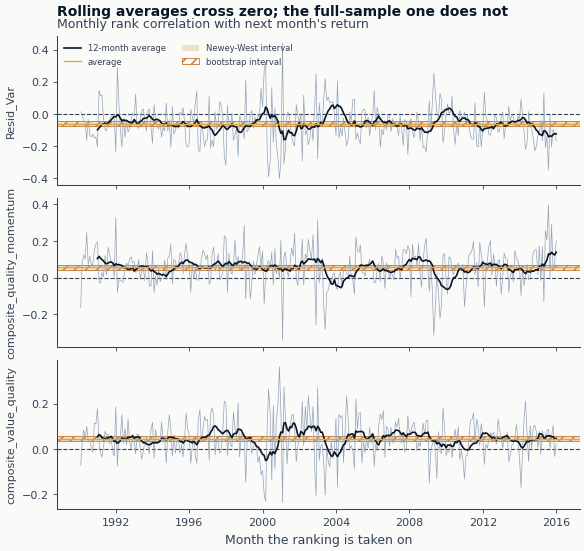

In [16]:
SERIES_FEATURES = leading_per_family(summary, 3)
ROLLING_MONTHS = 12

fig, axes = plt.subplots(len(SERIES_FEATURES), 1, figsize=FIGSIZE["grid_3x2"], sharex=True)
for ax, feature in zip(axes, SERIES_FEATURES, strict=True):
    series = ic_series[feature]
    stats = ic_stats[feature]
    bootstrap = compute_ic_uncertainty(series, horizon=LABEL_SPAN_MONTHS, ic_col="ic")
    half_width = 1.96 * stats["hac_se"]
    months = series[DATE_COL].to_list()
    ax.plot(months, series["ic"].to_list(), color=COLORS["recede"], linewidth=0.5)
    ax.plot(
        months,
        series["ic"].rolling_mean(ROLLING_MONTHS, min_samples=ROLLING_MONTHS).to_list(),
        color=COLORS["blue"],
        linewidth=1.2,
        label=f"{ROLLING_MONTHS}-month average",
    )
    ax.axhline(stats["mean_ic"], color=COLORS["amber"], linewidth=1.0, label="average")
    ax.axhspan(
        stats["mean_ic"] - half_width,
        stats["mean_ic"] + half_width,
        color=COLORS["amber"],
        alpha=0.3,
        lw=0,
        label="Newey-West interval",
    )
    ax.axhspan(
        bootstrap["ci_boot_lower"],
        bootstrap["ci_boot_upper"],
        facecolor="none",
        edgecolor=COLORS["copper"],
        hatch="///",
        lw=0.6,
        label="bootstrap interval",
    )
    zero_line(ax)
    ax.set_ylabel(feature, fontsize=8)
axes[0].legend(frameon=False, fontsize=6, ncols=2, loc="upper left")
axes[-1].set_xlabel("Month the ranking is taken on")
add_message_title(
    axes[0],
    "Rolling averages cross zero; the full-sample one does not",
    subtitle="Monthly rank correlation with next month's return",
)
show_with_alt(
    fig,
    "Three stacked time-series panels, one per characteristic. Each shows a noisy monthly "
    "rank correlation, a smoother twelve-month average that crosses zero repeatedly, and a "
    "flat full-sample average with two narrow intervals around it that do not reach zero.",
)

The interval around each average is narrow enough to be hard to see beside the month-to-month
swings, and that gap is the point of the figure. A single month's correlation is close to
worthless as evidence; three hundred of them average into something measurably different
from zero. The rolling average crossing zero repeatedly is what a characteristic with a
small but persistent edge looks like, and it is also what an unreliable characteristic looks
like - Section D is where the two are separated.

### How the characteristics compare

The averages are small in absolute terms, which is normal for a monthly cross-sectional
ranking and is not by itself a reason to discard one: a few hundredths of rank correlation
sustained across thousands of firms every month is a large amount of sorting power. The bars
are read against their intervals rather than against each other, and the interval is what
tells the reader whether two neighbouring bars are distinguishable at all.

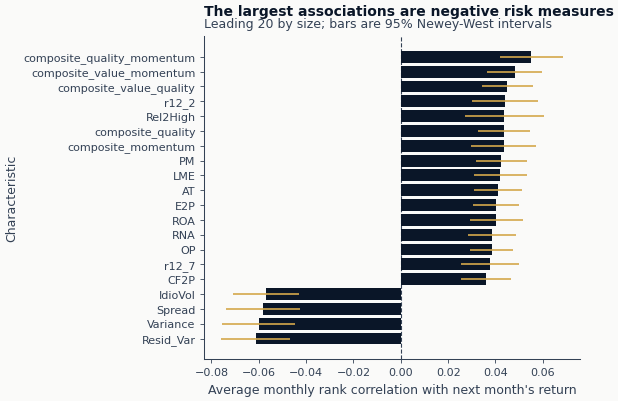

In [17]:
TOP_RANKED = 20
ranked = summary.head(TOP_RANKED).sort("ic_mean")

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    ranked["feature"].to_list(),
    ranked["ic_mean"].to_list(),
    xerr=[1.96 * se for se in ranked["hac_se"].to_list()],
    color=COLORS["blue"],
    error_kw={"ecolor": COLORS["amber"], "elinewidth": 1.2, "capsize": 2},
)
zero_line(ax, at=0, axis="x")
ax.set_xlabel("Average monthly rank correlation with next month's return")
ax.set_ylabel("Characteristic")
add_message_title(
    ax,
    "The largest associations are negative risk measures",
    subtitle=f"Leading {TOP_RANKED} by size; bars are 95% Newey-West intervals",
)
show_with_alt(
    fig,
    "Horizontal bars of average monthly rank correlation for twenty characteristics, with "
    "error bars. Four risk characteristics extend left of zero to about -0.06 and the rest "
    "extend right to about +0.05; no error bar reaches zero.",
)

## D. Fold stability: the same association throughout, or one episode

The average over the whole development period hides when the association happened. The same
average can come from a characteristic that works a little every year or from one that did
nothing for two decades and then worked spectacularly for eighteen months, and only the
first is worth trading.

So the monthly series is cut into the validation windows of the walk-forward scheme and
averaged inside each one. Three summaries of the result are reported: the middle window, the
spread between the middle half of the windows, and the window in which the association was
most negative. Agreement is then the share of windows pointing the same way as the
characteristic's own overall direction, which is what makes a consistently negative
characteristic score as high as a consistently positive one.

In [18]:
fold_stats: dict[str, dict] = {}
for feature, series in ic_series.items():
    fold_ics = []
    for fold in FOLDS:
        window = series.filter(pl.col(DATE_COL).is_between(fold["val_start"], fold["val_end"]))
        if window.height >= MIN_FOLD_MONTHS:
            fold_ics.append(float(window["ic"].mean()))
    if not fold_ics:
        continue
    overall_positive = ic_stats[feature]["mean_ic"] > 0
    fold_stats[feature] = {
        "fold_ics": fold_ics,
        "n_folds": len(fold_ics),
        "sign_consistency": sum((ic > 0) == overall_positive for ic in fold_ics) / len(fold_ics),
        "median_fold_ic": float(np.median(fold_ics)),
        "fold_iqr": float(np.percentile(fold_ics, 75) - np.percentile(fold_ics, 25)),
        "worst_fold_ic": min(fold_ics),
        "best_fold_ic": max(fold_ics),
    }

print(
    f"Per-window averages for {len(fold_stats)} characteristics over {len(FOLDS)} windows; "
    f"{sum(1 for s in fold_stats.values() if s['sign_consistency'] == 1.0)} point the same "
    "way in every window"
)

Per-window averages for 57 characteristics over 10 windows; 16 point the same way in every window


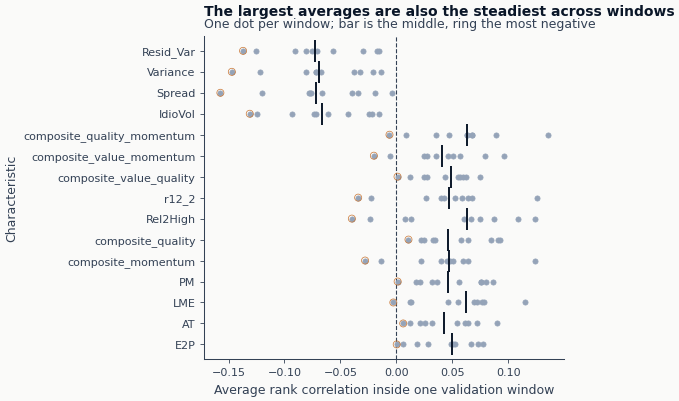

In [19]:
STABILITY_FEATURES = summary.head(15)["feature"].to_list()

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
for row, feature in enumerate(reversed(STABILITY_FEATURES)):
    stats = fold_stats[feature]
    ax.scatter(
        stats["fold_ics"],
        [row] * stats["n_folds"],
        s=14,
        color=COLORS["recede"],
        zorder=2,
    )
    ax.scatter([stats["median_fold_ic"]], [row], marker="|", s=260, color=COLORS["blue"], zorder=3)
    ax.scatter(
        [stats["worst_fold_ic"]],
        [row],
        marker="o",
        s=26,
        facecolor="none",
        edgecolor=COLORS["copper"],
        zorder=4,
    )
ax.set_yticks(range(len(STABILITY_FEATURES)))
ax.set_yticklabels(list(reversed(STABILITY_FEATURES)))
zero_line(ax, at=0, axis="x")
ax.set_xlabel("Average rank correlation inside one validation window")
ax.set_ylabel("Characteristic")
add_message_title(
    ax,
    "The largest averages are also the steadiest across windows",
    subtitle="One dot per window; bar is the middle, ring the most negative",
)
show_with_alt(
    fig,
    "A strip plot with one row per characteristic. The four rows with the largest averages "
    "keep every dot on one side of zero; most of the remaining rows have dots on both sides. "
    "A vertical bar marks the middle window and an open ring the most negative.",
)

## E. Shape: is the relationship one a ranking can use

The correlation says the ranking points the right way on average; it does not say the
relationship is steady across the range. A characteristic whose middle firms do best and
whose extremes both do badly can carry almost no rank correlation while still being highly
informative, and it needs a model that can express that shape.

So the firms are sorted into five equally sized groups by the characteristic **inside each
month**, and the return of each group is averaged. Assigning the groups within the month is
what makes the diagnostic answer the same question the correlation does: a firm's group is
its standing against the firms trading beside it, not against a different decade's
distribution.

Two summaries of each group are drawn. The average is what a book holding every firm in the
group earns; the middle firm is where the typical member of the group ends up. In a wide
equity cross-section these can point in opposite directions, because a handful of very
large positive returns move an average and cannot move a middle.

In [20]:
GROUP_INDEX = (
    ((pl.col("_x").rank("average").over(DATE_COL) - 1) * N_QUANTILES / pl.len().over(DATE_COL))
    .floor()
    .clip(0, N_QUANTILES - 1)
)

quantile_profiles: dict[str, dict] = {}
monotonicity: dict[str, float] = {}
for feature in ic_stats:
    valid = eval_panel.select([DATE_COL, pl.col(feature).alias("_x"), LABEL_NAME]).drop_nulls()
    profile = (
        valid.with_columns(GROUP_INDEX.cast(pl.Int8).alias("group"))
        .group_by(DATE_COL, "group")
        .agg(
            pl.col(LABEL_NAME).mean().alias("mean"),
            pl.col(LABEL_NAME).median().alias("middle"),
        )
        .group_by("group")
        .agg(pl.col("mean").mean(), pl.col("middle").mean())
        .sort("group")
    )
    if profile.height != N_QUANTILES:
        continue
    means = profile["mean"].to_list()
    quantile_profiles[feature] = {"means": means, "middles": profile["middle"].to_list()}
    monotonicity[feature] = float(spearmanr(range(N_QUANTILES), means)[0])

print(f"Group profile built for {len(quantile_profiles)} characteristics")

Group profile built for 57 characteristics


In [21]:
def wrap_name(name: str, width: int = 17) -> str:
    """Break a characteristic's name at its underscores so a panel label fits."""
    parts = textwrap.wrap(name.replace("_", "_ "), width, break_long_words=False)
    return "\n".join(parts).replace("_ ", "_")

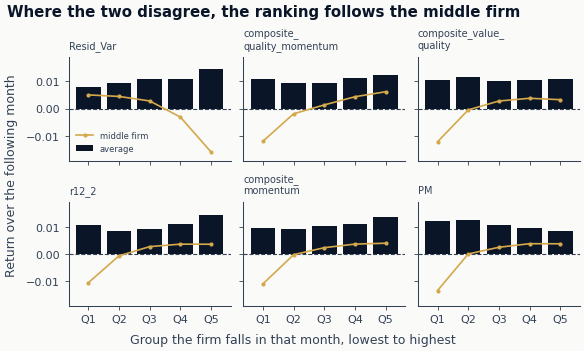

In [22]:
shown = [f for f in leading_per_family(summary, 6) if f in quantile_profiles]
extremes = [v for f in shown for k in ("means", "middles") for v in quantile_profiles[f][k]]
y_limit = max(abs(min(extremes)), abs(max(extremes))) * 1.2
groups = [f"Q{i + 1}" for i in range(N_QUANTILES)]

fig, axes = plt.subplots(2, 3, figsize=FIGSIZE["grid_2x3"], sharey=True, sharex=True)
for ax in axes.flat[len(shown) :]:
    ax.set_visible(False)
for ax, feature in zip(axes.flat, shown, strict=False):
    ax.bar(groups, quantile_profiles[feature]["means"], color=COLORS["blue"], label="average")
    ax.plot(
        groups,
        quantile_profiles[feature]["middles"],
        color=COLORS["amber"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="middle firm",
    )
    zero_line(ax)
    ax.set_ylim(-y_limit, y_limit)
    ax.set_title(wrap_name(feature), fontsize=7)
axes.flat[0].legend(frameon=False, fontsize=6, loc="lower left")
fig.supylabel("Return over the following month", fontsize=9)
fig.supxlabel("Group the firm falls in that month, lowest to highest", fontsize=9)
fig.suptitle(
    "Where the two disagree, the ranking follows the middle firm",
    color=COLORS["blue"],
    fontweight="semibold",
    x=0.01,
    ha="left",
)
show_with_alt(
    fig,
    "Six panels, one per characteristic, each with five bars for the average return of each "
    "group and a line for the middle firm. The two rise together in four panels; in the other "
    "two the bars and the line slope in opposite directions.",
)

Where the two series slope in opposite directions, the disagreement is worth more than
either alone. It says the extreme groups hold a few firms whose returns are large enough to
set the group's average while leaving the typical member of that group where it was. A
characteristic whose average climbs while its middle firm falls is one whose payoff sits in
a handful of names in the top group, which is a different proposition to hold and to size
than one that lifts the whole group.

In both panels where they disagree, the direction of the rank correlation reported in
Section C follows the middle firm rather than the average. A rank statistic counts how many
firms are in the right order and cannot be moved by how far the outliers reach, which is
why it reads these panels the way it does.

The shape score recorded in the ledger is the rank correlation between the group number and
the group's average return, which is +1 for a profile that rises all the way across and -1
for one that falls all the way. It is a description of the shape, and no part of the
decision rule in Section H reads it.

## F. Search accounting: what was searched, and what that costs

A p-value answers "how often would noise alone produce an association this strong", and it
is only interpretable next to a statement of how many associations were looked at. Testing
the whole candidate set at the conventional level and reporting the ones that clear it
produces a handful of significant results from pure noise, every time.

The searched set here is the whole candidate set against one label. The label is not itself
a search: the other two the case study declares are a winsorized and a two-class version of
this same monthly return, not different horizons or different definitions. Nor is the
candidate set the product of a grid this notebook ran - the released characteristics come
with the data, and the eleven constructed ones were fixed by a rule in the previous notebook
before any of them was scored.

The **Benjamini-Hochberg** procedure controls the share of the results declared significant
that are false, rather than the chance of any false result at all. That is the right target
here: this is a screen whose output is a list to look at further, so a few false entries
cost less than discarding real ones.

In [23]:
fdr = benjamini_hochberg_fdr(summary["hac_p"].to_list(), alpha=FDR_ALPHA, return_details=True)
summary = summary.with_columns(
    fdr_p=pl.Series(list(fdr["adjusted_p_values"])),
    fdr_sig=pl.Series(list(fdr["rejected"])),
)

n_naive = int((summary["naive_t"].abs() > 1.96).sum())
n_hac = int((summary["hac_p"] < FDR_ALPHA).sum())
n_fdr = int(fdr["n_rejected"])

print(
    f"Searched set: {len(CANDIDATES)} characteristics against 1 label, "
    f"{len(summary)} of them scored\n"
    f"  significant, independent months assumed  {n_naive}\n"
    f"  significant, Newey-West                  {n_hac}\n"
    f"  significant after Benjamini-Hochberg     {n_fdr}"
)

Searched set: 57 characteristics against 1 label, 57 of them scored
  significant, independent months assumed  41
  significant, Newey-West                  39
  significant after Benjamini-Hochberg     38


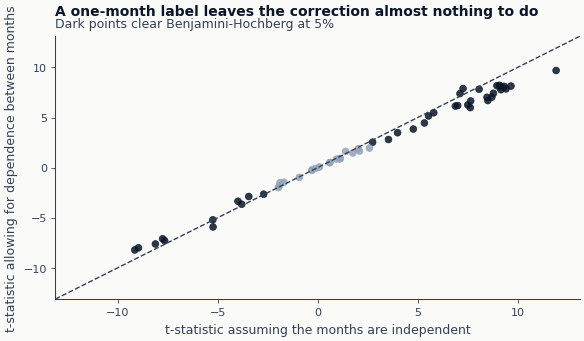

In [24]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
colors = [
    COLORS["blue"] if significant else COLORS["recede"]
    for significant in summary["fdr_sig"].to_list()
]
ax.scatter(summary["naive_t"].to_list(), summary["hac_t"].to_list(), c=colors, s=24, alpha=0.85)
limit = max(summary["naive_t"].abs().max(), summary["hac_t"].abs().max()) * 1.1
ax.plot([-limit, limit], [-limit, limit], linestyle="--", color=COLORS["neutral"], linewidth=1)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_xlabel("t-statistic assuming the months are independent")
ax.set_ylabel("t-statistic allowing for dependence between months")
add_message_title(
    ax,
    "A one-month label leaves the correction almost nothing to do",
    subtitle=f"Dark points clear Benjamini-Hochberg at {FDR_ALPHA:.0%}",
)
show_with_alt(
    fig,
    "A scatter of Newey-West against naive t-statistics for every scored characteristic. "
    "Points sit on the diagonal from about -9 to +12, and the light points that fail "
    "false-discovery control are the ones nearest the origin.",
)

57 characteristics were screened against one label over 312 month-ends of the development
period, on a cross-section running from 2,032 to 2,826 firms. The largest association in
absolute value is -0.0613 for Resid_Var, a residual variance measure that ranks firms the
other way up: the more idiosyncratic risk a firm carries, the worse it does the following
month. Allowing for dependence between months moves almost nothing - 41 characteristics
reach the usual threshold assuming independent months and 39 do so under Newey-West at the
5-lag bandwidth the length of the series calls for. A label whose observations do not
overlap asks for none of its own. Charging the search for its 57 tests removes one more and
leaves 38.

## G. Redundancy and families: the same evidence twice

Two characteristics that rank firms almost identically will both look significant and are
one piece of evidence, not two. Rank correlation between every pair of candidates is
computed over a sample of the months - enough to estimate the correlation, at a fraction of
the cost of every month - and the pairs above the redundancy cut are the ones worth naming.

In [25]:
sample_step = max(1, n_months // 200)
sample_months = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_matrix = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_months))
    .select(screened)
    .to_pandas()
    .corr(method="spearman")
)

pairs = [
    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
    for i in range(len(corr_matrix))
    for j in range(i + 1, len(corr_matrix))
    if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT
]

Naming pairs is not yet a decision. Redundancy comes in groups rather than couples - three
risk measures can all be near-copies of one another - so the characteristics are clustered
on how far apart they are, one minus the size of their correlation, and cut at the same
threshold. Section 8.6 keeps one member of each cluster: the one whose association is
strongest in the middle validation window, and among those the one whose association varies
least from window to window. Both of those numbers came out of Section D, so the choice is
a sort over columns already in hand.

The representative is a recommendation for a reader building a smaller feature set by hand.
It does not remove anything from the panel the models are trained on, and it does not excuse
a representative from earning its own decision below.

In [26]:
distance = np.nan_to_num(1.0 - corr_matrix.abs().to_numpy(), nan=1.0)
distance = (distance + distance.T) / 2.0
np.fill_diagonal(distance, 0.0)
cluster_ids = fcluster(
    linkage(squareform(distance, checks=False), method="single"),
    t=1.0 - REDUNDANCY_CUT,
    criterion="distance",
)
clusters: dict[int, list[str]] = {}
for feature, cluster_id in zip(screened, cluster_ids, strict=True):
    clusters.setdefault(int(cluster_id), []).append(feature)


def cluster_representative(members: list[str]) -> str:
    """The member with the strongest middle-window association and the least variation."""
    scored = [m for m in members if m in fold_stats]
    if not scored:
        return members[0]
    return max(
        scored,
        key=lambda m: (abs(fold_stats[m]["median_fold_ic"]), -fold_stats[m]["fold_iqr"]),
    )


REPRESENTATIVES = {
    cluster_representative(members): members for members in clusters.values() if len(members) > 1
}
grouped_features = sum(len(m) for m in REPRESENTATIVES.values())
print(
    f"Pairs correlated above {REDUNDANCY_CUT}: {len(pairs)}\n"
    f"Clusters of two or more: {len(REPRESENTATIVES)}, covering {grouped_features} "
    f"characteristics; {len(screened) - grouped_features} stand alone"
)

Pairs correlated above 0.7: 42
Clusters of two or more: 7, covering 32 characteristics; 25 stand alone


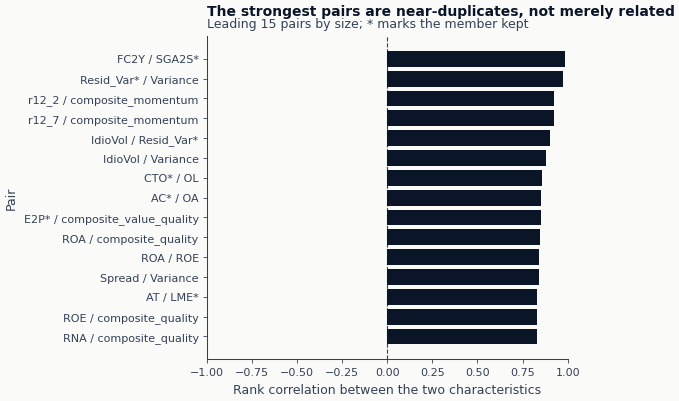

In [27]:
TOP_PAIRS = 15
strongest = sorted(pairs, key=lambda pair: abs(pair[2]), reverse=True)[:TOP_PAIRS]


def kept(feature: str) -> str:
    return f"{feature}*" if feature in REPRESENTATIVES else feature


pair_labels = [f"{kept(left)} / {kept(right)}" for left, right, _ in strongest]
pair_values = [value for _, _, value in strongest]
order = np.argsort(pair_values)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    [pair_labels[i] for i in order],
    [pair_values[i] for i in order],
    color=[COLORS["blue"] if pair_values[i] >= 0 else COLORS["copper"] for i in order],
)
zero_line(ax, at=0, axis="x")
ax.set_xlim(-1, 1)
ax.set_xlabel("Rank correlation between the two characteristics")
ax.set_ylabel("Pair")
add_message_title(
    ax,
    "The strongest pairs are near-duplicates, not merely related",
    subtitle=f"Leading {TOP_PAIRS} pairs by size; * marks the member kept",
)
show_with_alt(
    fig,
    "Horizontal bars for the fifteen most correlated pairs of characteristics, all between "
    "0.8 and 1.0, with an asterisk on the member kept as its cluster's representative.",
)

Both members of a drawn pair are in the same cluster by construction, so at most one of them
can be starred. A pair with no star at all is one whose cluster has a third member that beat
both: the choice is made once per cluster, not once per pair.

The same grouping supports a coarser reading. Averaging the size of the association within
each declared group says where the sorting power sits. It is a description and not a test:
the members of a group are correlated with each other by construction, so the average is
not an independent measurement, and the groups holding one or two constructed columns are
an average over that one column.

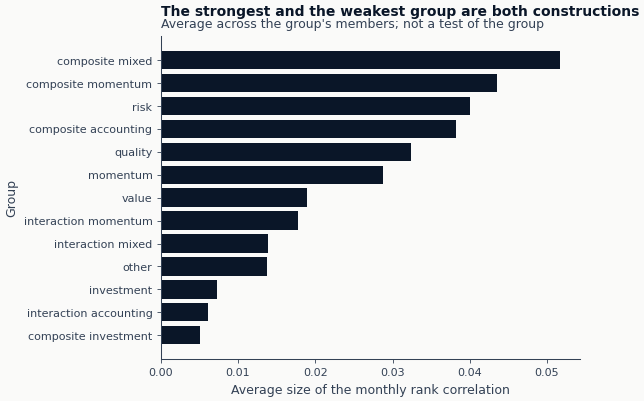

In [28]:
family_strength = (
    summary.group_by("family")
    .agg(
        pl.col("ic_mean").abs().mean().alias("mean_abs_ic"),
        pl.len().alias("characteristics"),
    )
    .sort("mean_abs_ic")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    family_strength["family"].to_list(),
    family_strength["mean_abs_ic"].to_list(),
    color=COLORS["blue"],
)
ax.set_xlabel("Average size of the monthly rank correlation")
ax.set_ylabel("Group")
add_message_title(
    ax,
    "The strongest and the weakest group are both constructions",
    subtitle="Average across the group's members; not a test of the group",
)
show_with_alt(
    fig,
    "Horizontal bars of the average absolute rank correlation for each declared group. The "
    "top and bottom bars are both groups of constructed columns, with the released groups "
    "spread between them.",
)

## H. Triage and handoff: what decision each characteristic gets

Every candidate gets one of three decisions and the reason it got it.

| Decision | Condition | Route |
|---|---|---|
| PROCEED | clears Benjamini-Hochberg at `FDR_ALPHA` | confirmation |
| PROCEED | agrees in direction across at least `MIN_SIGN_CONSISTENCY` of the windows, and its association is at least `IC_THRESHOLD` | exploration |
| STOP | coverage below `MIN_COVERAGE` | - |
| REVISE | everything else | - |

The two PROCEED conditions are alternatives, so the count of promotions can exceed the
count of significant results, and the ledger records which of the two fired for each
characteristic.

The second route is not a significance test and is not a correction to one. It is an
effect-size-and-steadiness filter, and it exists so that controlling false discoveries does
not empty a list whose purpose is to be looked at further. Section 7.4 calls this the
exploration pass, and a characteristic promoted through it has not been confirmed by
anything. Its threshold is a judgement rather than a derived quantity: `IC_THRESHOLD`,
printed in Configuration above, is roughly the association a monthly long-short book on this
universe needs before the round-trip cost of rebalancing it eats the spread between the top
and bottom group. Where that value sits in the distribution actually observed is reported
below, so a reader can see whether it is binding or decorative.

REVISE is not a rejection. A characteristic that carries nothing on its own can still earn
its place in a model that uses it alongside others, which is the question Chapter 11 asks
and this notebook does not.

In [29]:
significant = set(summary.filter(pl.col("fdr_sig"))["feature"].to_list())

decisions: dict[str, tuple[str, str]] = {}
for feature in CANDIDATES:
    if coverage[feature] < MIN_COVERAGE:
        decisions[feature] = ("STOP", "coverage_below_floor")
    elif feature not in ic_stats:
        decisions[feature] = ("REVISE", "too_few_scored_months")
    elif feature in significant:
        decisions[feature] = ("PROCEED", "false_discovery_controlled")
    elif (
        fold_stats.get(feature, {}).get("sign_consistency", 0.0) >= MIN_SIGN_CONSISTENCY
        and abs(ic_stats[feature]["mean_ic"]) >= IC_THRESHOLD
    ):
        decisions[feature] = ("PROCEED", "steady_and_above_threshold")
    else:
        decisions[feature] = ("REVISE", "not_significant_alone")

ledger = pl.DataFrame(
    [
        {
            "feature": feature,
            "family": FAMILIES[feature],
            "source": "financial",
            "coverage": coverage[feature],
            "ic_mean": ic_stats.get(feature, {}).get("mean_ic"),
            "hac_t": ic_stats.get(feature, {}).get("t_stat"),
            "hac_p": ic_stats.get(feature, {}).get("p_value"),
            "sign_consistency": fold_stats.get(feature, {}).get("sign_consistency"),
            "median_fold_ic": fold_stats.get(feature, {}).get("median_fold_ic"),
            "fold_iqr": fold_stats.get(feature, {}).get("fold_iqr"),
            "worst_fold_ic": fold_stats.get(feature, {}).get("worst_fold_ic"),
            "best_fold_ic": fold_stats.get(feature, {}).get("best_fold_ic"),
            "monotonicity": monotonicity.get(feature),
            "cluster_representative": feature in REPRESENTATIVES,
            "decision": decisions[feature][0],
            "note": decisions[feature][1],
        }
        for feature in CANDIDATES
    ]
).join(summary.select("feature", "fdr_p", "fdr_sig"), on="feature", how="left")

ledger_record = write_artifact(
    ledger,
    EVAL_DIR / "triage_ledger.parquet",
    keys=["feature"],
    written_by="04_evaluation",
    inputs={"financial": features_record["digest"], LABEL_NAME: label_record["digest"]},
)
print(
    f"{display_path(EVAL_DIR / 'triage_ledger.parquet')}: "
    f"{ledger_record['n_rows']} rows, digest {ledger_record['digest']}"
)

case_studies/us_firm_characteristics/evaluation/triage_ledger.parquet: 57 rows, digest 200f945ac0727f6a


In [30]:
ic_frame = pl.concat(
    series.with_columns(pl.lit(feature).alias("feature")) for feature, series in ic_series.items()
)
ic_record = write_artifact(
    ic_frame,
    EVAL_DIR / "ic_timeseries.parquet",
    keys=["feature", DATE_COL],
    written_by="04_evaluation",
    inputs={"financial": features_record["digest"], LABEL_NAME: label_record["digest"]},
)
print(
    f"{display_path(EVAL_DIR / 'ic_timeseries.parquet')}: "
    f"{ic_record['n_rows']:,} rows, digest {ic_record['digest']}"
)

case_studies/us_firm_characteristics/evaluation/ic_timeseries.parquet: 17,784 rows, digest c068ec4bbbf6594b


The funnel is what the search cost. Every candidate clearing coverage is scored; the
confirmation route keeps the ones that survive the correction for having looked at 57 of
them; the exploration route adds the ones whose direction holds across the windows at an
association worth a monthly rebalance. The two routes are drawn apart because a reader
seeing only the total cannot tell how much of the list was confirmed and how much was
carried forward on steadiness alone.

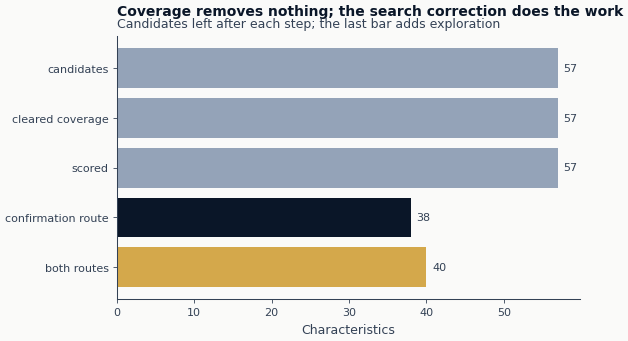

In [31]:
promoted = [f for f, (decision, _) in decisions.items() if decision == "PROCEED"]
confirmed = [f for f, (_, note) in decisions.items() if note == "false_discovery_controlled"]
explored = [f for f, (_, note) in decisions.items() if note == "steady_and_above_threshold"]

funnel = [
    ("candidates", len(CANDIDATES), COLORS["recede"]),
    ("cleared coverage", len(screened), COLORS["recede"]),
    ("scored", len(ic_stats), COLORS["recede"]),
    ("confirmation route", len(confirmed), COLORS["blue"]),
    ("both routes", len(promoted), COLORS["amber"]),
]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh([step for step, _, _ in funnel], [n for _, n, _ in funnel], color=[c for _, _, c in funnel])
for row, (_, count, _) in enumerate(funnel):
    ax.annotate(
        str(count),
        xy=(count, row),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )
ax.invert_yaxis()
ax.set_xlabel("Characteristics")
add_message_title(
    ax,
    "Coverage removes nothing; the search correction does the work",
    subtitle="Candidates left after each step; the last bar adds exploration",
)
show_with_alt(
    fig,
    "A horizontal funnel of five bars falling from 57 candidates through 57 scored to 38 "
    "promoted on the confirmation route and 40 on both routes together.",
)

In [32]:
observed = summary["ic_mean"].abs().to_list()
print(
    f"PROCEED {len(promoted)}, "
    f"REVISE {sum(1 for d, _ in decisions.values() if d == 'REVISE')}, "
    f"STOP {sum(1 for d, _ in decisions.values() if d == 'STOP')}\n"
    f"  confirmation route {len(confirmed)}, exploration route {len(explored)}\n"
    f"  the {IC_THRESHOLD} threshold sits at the "
    f"{sum(v < IC_THRESHOLD for v in observed) / len(observed):.0%} point of the "
    f"{len(observed)} associations actually observed"
)

PROCEED 40, REVISE 17, STOP 0
  confirmation route 38, exploration route 2
  the 0.01 threshold sits at the 35% point of the 57 associations actually observed


40 of the 57 characteristics are promoted: 38 through the confirmation route and 2 through
the exploration route, with the remaining 17 marked for reconsideration in a model that uses
several at once. None is stopped, because coverage never falls below the floor. The
exploration threshold of 0.01 sits at the 35% point of the associations observed here, so it
is binding on the weakest third of the list rather than decorative - but the two
characteristics it promotes on its own, the two market-beta measures, are the whole of its
effect here. Redundancy accounts for more of the list than either route does: 7 clusters
hold 32 of the 57, so a reader building a smaller set by hand starts from 25 characteristics
that stand alone plus one representative from each cluster.

## Key takeaways

1. **A cross-section this wide makes significance the easy part.** With thousands of firms
   ranked every month for three hundred months, the average correlation is measured
   precisely enough that small associations clear any conventional threshold. The question
   that separates the candidates is therefore not whether the association is distinguishable
   from zero but whether it is large enough to trade and steady enough to rely on, which is
   why effect size and window-to-window agreement both enter the decision rule.

2. **Report the size of the search beside every p-value.** The correction applied here
   depends on how many characteristics were looked at, so a reader cannot check it without
   that count. Adding a candidate after seeing the results changes every p-value in the
   table, which is why the candidate set is fixed by the previous notebook.

3. **Average one correlation per period rather than pooling the rows.** Pooling weights
   each period by how many entities it happened to contain, so the answer moves with the
   shape of the panel as well as with the signal. The same argument sets the group
   boundaries within each month rather than over the pooled sample.

4. **Near-duplicates inflate how much a promoted list appears to hold.** The multiplicity
   correction treats every test as separate, which is the conservative choice about false
   discoveries and says nothing about how many distinct findings survive: three variance
   measures that rank firms identically clear it three times. Clustering on correlation and
   naming one member per cluster is what tells a reader how much of the list is repetition.
   Nothing above is counted over representatives, so it informs the reader rather than the
   rule.

**What this evaluation cannot settle.** It measures each characteristic on its own, so it
says nothing about one that only works conditional on another, and nothing about what a
model combining them can extract. It measures the ranking, not the trade: no cost, no
position size and no capacity constraint enters any number here. And every measurement is
taken over the development period, so it describes a relationship that held in the past and
is not evidence that it will hold in the held-back period, which nothing here has read.

**Next**: [`05_linear`](05_linear.ipynb) fits regularized linear models over the whole
characteristic panel, which is the first place these characteristics are used together
rather than one at a time.